<a href="https://colab.research.google.com/github/AjitShetti/AjitShetti/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Tue Mar 17 03:54:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device



2.10.0+cu128


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

In [3]:
# Automatic cars
# Multiclass classification
# Segmentation

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

In [4]:
# Overfitting in machine learning occurs when the model learns too much from the training data along with the noise and fluctuations which causes error while testing that ML model

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

In [5]:
'''
1. Data Augmentation
2. Training on a big dataset
3. Regularization
'''

'\n1. Data Augmentation\n2. Training on a big dataset\n3. Regularization\n'

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [6]:
from torchvision import datasets
from torchvision.transforms import ToTensor

## 6. Visualize at least 5 different samples of the MNIST training dataset.

In [7]:
train_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor(),)

test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor(),)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 198kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.3MB/s]


## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [8]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)

test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [11]:
from torch import nn

class FashionMNISTV2(nn.Module):
  def __init__(self, input_shape : int, hidden_units : int, output_shape : int):
    super().__init__()
    self.block1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    ),

    self.block2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    ),

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )


    def forward(self, x):
      x = self.block1(x)
      x = self.block2(x)

      return x

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [14]:
import torch
from torch import nn
from tqdm.auto import tqdm
from timeit import default_timer as timer

# Redefining the FashionMNISTV2 model with corrections, as the original definition
# in the previous cell had some issues (e.g., nn.Conv2 instead of nn.Conv2d,
# incorrect block initialization, and incomplete forward method).
class FashionMNISTV2(nn.Module):
  def __init__(self, input_shape : int, hidden_units : int, output_shape : int):
    super().__init__()
    self.block1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.block2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units, out_channels=hidden_units, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, # Assuming input image size of 28x28, after two MaxPool2d layers (kernel_size=2, stride=2), it becomes 7x7
                  out_features=output_shape)
    )

  def forward(self, x: torch.Tensor):
    x = self.block1(x)
    x = self.block2(x)
    x = self.classifier(x)
    return x

# Helper function to calculate accuracy
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device):
    model.train()
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1))

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(y_true=y,
                                    y_pred=test_pred.argmax(dim=1))

        test_loss /= len(dataloader)
        test_acc /= len(dataloader)
        return test_loss, test_acc

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          accuracy_fn,
          epochs: int,
          device: torch.device):

    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           accuracy_fn=accuracy_fn,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        accuracy_fn=accuracy_fn,
                                        device=device)

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.2f}% | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.2f}%"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

# Setup hyperparameters
NUM_EPOCHS = 5
LEARNING_RATE = 0.01

# 1. Train on CPU
print("Training on CPU...")
cpu_device = "cpu"
torch.manual_seed(42)

# Re-instantiate the model for CPU training
model_cpu = FashionMNISTV2(input_shape=1,
                           hidden_units=10,
                           output_shape=len(train_data.classes)).to(cpu_device)

loss_fn = nn.CrossEntropyLoss()
optimizer_cpu = torch.optim.SGD(params=model_cpu.parameters(),
                                lr=LEARNING_RATE)

start_time_cpu = timer()
train_results_cpu = train(model=model_cpu,
                          train_dataloader=train_dataloader,
                          test_dataloader=test_dataloader,
                          optimizer=optimizer_cpu,
                          loss_fn=loss_fn,
                          accuracy_fn=accuracy_fn,
                          epochs=NUM_EPOCHS,
                          device=cpu_device)
end_time_cpu = timer()
total_time_cpu = end_time_cpu - start_time_cpu
print(f"Total training time on CPU: {total_time_cpu:.3f} seconds\n")

# 2. Train on GPU (if available)
if torch.cuda.is_available():
    print("Training on GPU...")
    gpu_device = "cuda"
    torch.manual_seed(42)

    # Re-instantiate the model for GPU training (with random weights)
    model_gpu = FashionMNISTV2(input_shape=1,
                               hidden_units=10,
                               output_shape=len(train_data.classes)).to(gpu_device)

    optimizer_gpu = torch.optim.SGD(params=model_gpu.parameters(),
                                    lr=LEARNING_RATE)

    start_time_gpu = timer()
    train_results_gpu = train(model=model_gpu,
                              train_dataloader=train_dataloader,
                              test_dataloader=test_dataloader,
                              optimizer=optimizer_gpu,
                              loss_fn=loss_fn,
                              accuracy_fn=accuracy_fn,
                              epochs=NUM_EPOCHS,
                              device=gpu_device)
    end_time_gpu = timer()
    total_time_gpu = end_time_gpu - start_time_gpu
    print(f"Total training time on GPU: {total_time_gpu:.3f} seconds")
else:
    print("GPU not available, skipping GPU training.")

Training on CPU...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0355 | train_acc: 62.31% | test_loss: 0.6446 | test_acc: 77.08%
Epoch: 2 | train_loss: 0.5519 | train_acc: 79.96% | test_loss: 0.5250 | test_acc: 80.56%
Epoch: 3 | train_loss: 0.4553 | train_acc: 83.55% | test_loss: 0.4544 | test_acc: 83.84%
Epoch: 4 | train_loss: 0.4116 | train_acc: 85.16% | test_loss: 0.4071 | test_acc: 85.71%
Epoch: 5 | train_loss: 0.3858 | train_acc: 86.14% | test_loss: 0.3954 | test_acc: 86.25%
Total training time on CPU: 179.616 seconds

Training on GPU...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0355 | train_acc: 62.33% | test_loss: 0.6451 | test_acc: 77.04%
Epoch: 2 | train_loss: 0.5522 | train_acc: 79.94% | test_loss: 0.5272 | test_acc: 80.49%
Epoch: 3 | train_loss: 0.4559 | train_acc: 83.56% | test_loss: 0.4542 | test_acc: 83.85%
Epoch: 4 | train_loss: 0.4123 | train_acc: 85.14% | test_loss: 0.4077 | test_acc: 85.77%
Epoch: 5 | train_loss: 0.3865 | train_acc: 86.13% | test_loss: 0.3968 | test_acc: 86.22%
Total training time on GPU: 60.660 seconds


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

# Task
Prepare the trained model for evaluation, obtain a sample batch from the test dataloader, make predictions, and then visualize at least 5 images along with their true and predicted labels.

## Prepare for prediction

### Subtask:
Set the trained model to evaluation mode and get a sample batch from the test dataloader.


**Reasoning**:
Set the trained model to evaluation mode and retrieve a single batch of data from the test dataloader as instructed.



In [15]:
model_gpu.eval()
test_samples_images, test_samples_labels = next(iter(test_dataloader))

## Make predictions

### Subtask:
Pass the sample batch through the model to get predictions.


**Reasoning**:
The next step is to pass the sample batch through the model to obtain predictions, convert them to probabilities, then to predicted labels, and finally move the labels to the CPU as instructed.



In [16]:
model_gpu.eval()
with torch.inference_mode():
    test_samples_images = test_samples_images.to(gpu_device)
    y_logits = model_gpu(test_samples_images)

y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_labels = y_pred_probs.argmax(dim=1)
y_pred_labels_cpu = y_pred_labels.cpu()

print(f"Raw Logits shape: {y_logits.shape}")
print(f"Predicted probabilities shape: {y_pred_probs.shape}")
print(f"Predicted labels shape: {y_pred_labels_cpu.shape}")

Raw Logits shape: torch.Size([32, 10])
Predicted probabilities shape: torch.Size([32, 10])
Predicted labels shape: torch.Size([32])


**Reasoning**:
To visualize the predictions, I need to plot at least 5 sample images from the test set, displaying their true labels and the labels predicted by the model. This involves iterating through a subset of the test samples, using matplotlib to display the images, and retrieving the corresponding true and predicted class names.



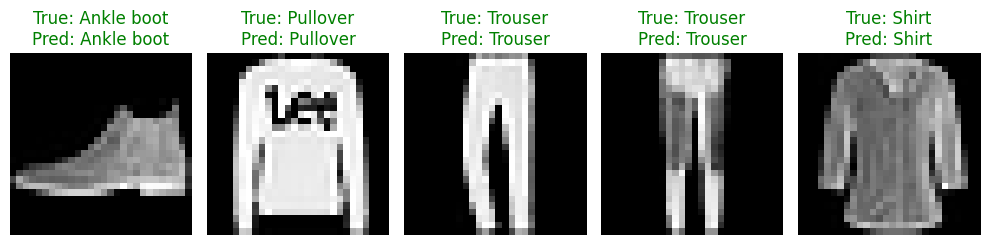

In [17]:
import matplotlib.pyplot as plt

# Get class names from the training data
class_names = train_data.classes

# Plot at least 5 predictions
num_samples_to_plot = 5
plt.figure(figsize=(10, 10))
for i in range(num_samples_to_plot):
    # Get image, true label, and predicted label
    image = test_samples_images[i].cpu().squeeze()
    true_label = class_names[test_samples_labels[i]]
    pred_label = class_names[y_pred_labels_cpu[i]]

    # Plot the image
    plt.subplot(1, num_samples_to_plot, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"True: {true_label}\nPred: {pred_label}", color='green' if true_label == pred_label else 'red')
    plt.axis(False)

plt.tight_layout()
plt.show()

## Summary:

### Q&A
Yes, at least 5 images were successfully visualized along with their true and predicted labels, providing a visual assessment of the model's performance.

### Data Analysis Key Findings
*   The trained model was successfully set to evaluation mode, ensuring consistent predictions by disabling training-specific layers like dropout and batch normalization.
*   A sample batch of images and their corresponding true labels was successfully obtained from the test dataloader.
*   The model processed the sample batch, producing raw logits with a shape of `torch.Size([32, 10])`, indicating predictions for 32 samples across 10 possible classes.
*   These logits were converted into predicted probabilities (shape `torch.Size([32, 10])`) and then into predicted class labels (shape `torch.Size([32])`).
*   Five sample images from the test set were visualized, displaying both their true and predicted class labels. The visualization clearly indicated instances where the model's prediction matched the true label (green text) and where it did not (red text).

### Insights or Next Steps
*   The successful visualization confirms the model's basic predictive capability and provides immediate qualitative feedback on its performance.
*   To obtain a comprehensive understanding of the model's performance, the next step should involve calculating quantitative evaluation metrics (e.g., accuracy, precision, recall, F1-score) on the entire test dataset.
